# 02 - Pembersihan Data & Anotasi (Sentimen & Emosi)

Notebook ini menggabungkan dua tahap sekaligus:
1. **Pembersihan Data & EDA:** Menghapus duplikat, menangani nilai kosong (Missing Values), dan melakukan Exploratory Data Analysis awal.
2. **Anotasi Data:** Menambahkan kolom **Sentiment** dan **Emotion** menggunakan perpaduan **Rating Bintang (Rules)** dan **Model NLP pra-latih (Pre-trained Models)** berbahasa Indonesia.

In [4]:
# Install library yang dibutuhkan
%pip install pandas matplotlib seaborn transformers torch tqdm ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
from tqdm import tqdm
import re

tqdm.pandas()
sns.set_theme(style="whitegrid")

## 1. Load Dataset Hasil Scraping

In [6]:
INPUT_CSV = "dataset\\raw-2_tokopedia_dataset.csv"
OUTPUT_CSV = "dataset\\annotated-2_tokopedia_dataset.csv"

df = pd.read_csv(INPUT_CSV)
print(f"Total Data Awal: {len(df)} baris")
display(df.head(3))

Total Data Awal: 19934 baris


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review
0,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,"alhamdulillah udah sampek ,bneran 2liter lhoo,..."
1,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,Paket minyak sunco di terima dgn baik... Minya...
2,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,Mantap dapat harga murce ditengah2 mahalnya mi...


In [10]:
file_path = "dataset\\raw-2_tokopedia_dataset.csv"

df = pd.read_csv(file_path)
df['Category'] = df['Category'].str.title()

df.to_csv(file_path, index=False)

display(df.head())
print("Kategori berhasil diubah menjadi huruf kapital!")


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review
0,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,"alhamdulillah udah sampek ,bneran 2liter lhoo,..."
1,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,Paket minyak sunco di terima dgn baik... Minya...
2,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,Mantap dapat harga murce ditengah2 mahalnya mi...
3,Minyak Goreng 2 Liter,SunCo Minyak Goreng 2 Liter - Minyak Goreng Ba...,Surabaya,59500,5.0,1,34,5,Kualitas produk sangat baik serta original Har...
4,Minyak Goreng 2 Liter,SUNCO COOKING OIL REFILL 2 LITER - MINYAK GORENG,Unknown,49210,5.0,3,30,5,"barangnya sesuai dengan pesanan, pengiriman ba..."


Kategori berhasil diubah menjadi huruf kapital!


## 2. Pembersihan Data (Missing Values & Duplicates)

In [11]:
print("=== Penanganan Missing Values ===")
print("Jumlah NaN sebelum dibersihkan:")
print(df.isnull().sum())

# Isi ulasan kosong dengan string kosong, rating kosong dengan 0
df['Customer Review'] = df['Customer Review'].fillna("")
df['Customer Rating'] = df['Customer Rating'].fillna(0)

print("\n=== Penghapusan Data Duplikat ===")
total_sebelum = len(df)
# Hapus duplikat berdasarkan Nama Produk dan Ulasan (untuk mencegah ulasan yang sama ter-scrape 2x)
df = df.drop_duplicates(subset=['Product Name', 'Customer Review'], keep='first')

total_setelah = len(df)
duplikat_terhapus = total_sebelum - total_setelah
print(f"Total Data Duplikat yang Dihapus: {duplikat_terhapus} baris")
print(f"Total Data Bersih yang Siap Dianotasi: {total_setelah} baris")

=== Penanganan Missing Values ===
Jumlah NaN sebelum dibersihkan:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     1
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
dtype: int64

=== Penghapusan Data Duplikat ===
Total Data Duplikat yang Dihapus: 3261 baris
Total Data Bersih yang Siap Dianotasi: 16673 baris


## 3. Exploratory Data Analysis (EDA) Awal

=== Top 5 Kategori Produk Terbanyak ===


Category
Sprei Aesthetic         392
Celana Jeans Wanita     391
Pasta Gigi Whitening    386
Ikat Pinggang Kulit     386
Kasur Busa              385
Name: count, dtype: int64

C:\Users\Rafie Zaidan U\AppData\Local\Temp\ipykernel_11380\905125079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")


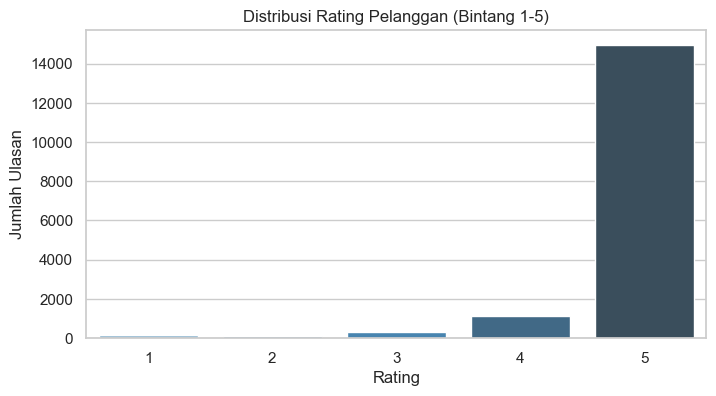

In [12]:
print("=== Top 5 Kategori Produk Terbanyak ===")
display(df['Category'].value_counts().head())

plt.figure(figsize=(8, 4))
rating_counts = df['Customer Rating'].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="Blues_d")
plt.title('Distribusi Rating Pelanggan (Bintang 1-5)')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

## 4. Inisialisasi Model AI & Fungsi Anotasi
*(Catatan: Membersihkan duplikat di atas sangat membantu menghemat waktu pemrosesan AI di tahap ini!)*

In [13]:
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    print("Menggunakan GPU")
else:
    print("Menggunakan CPU")

sentiment_pipeline = pipeline("text-classification", model="w11wo/indonesian-roberta-base-sentiment-classifier", device=device)
emotion_pipeline = pipeline("text-classification", model="StevenLimcorn/indonesian-roberta-base-emotion-classifier", device=device)
print("Model berhasil dimuat!")

Menggunakan CPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat!


In [14]:
def get_sentiment(row):
    text = str(row['Customer Review']).strip()
    try: rating = float(row['Customer Rating'])
    except: rating = 0.0
        
    if text == "" or text.lower() == "nan": return "Neutral"

    is_short = len(text) < 50
    positive_words = ['nice', 'good', 'mantap', 'bagus', 'ok', 'oke', 'keren', 'sip', 'jos', 'top', 'best']
    has_pos_word = any(w in text.lower() for w in positive_words)
    
    if rating >= 4.0 and (is_short or has_pos_word): return "Positive"
    elif rating <= 2.0 and is_short: return "Negative"

    try:
        short_text = text[:1500] 
        result = sentiment_pipeline(short_text)[0]
        label = result['label'].lower()
        if label == 'positive': return "Positive"
        elif label == 'negative': return "Negative"
        else: return "Neutral"
    except Exception: return "Neutral"

def get_emotion(row):
    text = str(row['Customer Review']).strip()
    try: rating = float(row['Customer Rating'])
    except: rating = 0.0
        
    if text == "" or text.lower() == "nan": return "None"

    is_short = len(text) < 50
    positive_words = ['nice', 'good', 'mantap', 'bagus', 'ok', 'oke', 'keren', 'sip', 'jos', 'top', 'best', 'suka']
    has_pos_word = any(w in text.lower() for w in positive_words)
    
    if rating >= 4.0 and (is_short or has_pos_word): return "Happy"
    elif rating <= 2.0 and is_short: return "Anger"

    try:
        short_text = text[:1500]
        result = emotion_pipeline(short_text)[0]
        label = result['label'].lower()
        if label == 'happy': return "Happy"
        elif label == 'sadness': return "Sadness"
        elif label == 'anger': return "Anger"
        elif label == 'fear': return "Fear"
        elif label == 'love': return "Love"
        else: return label.capitalize()
    except Exception: return "None"

## 5. Eksekusi Anotasi

In [ ]:
print("Ekstraksi Sentimen...")
df['Sentiment'] = df.progress_apply(get_sentiment, axis=1)

print("Ekstraksi Emosi...")
df['Emotion'] = df.progress_apply(get_emotion, axis=1)

Ekstraksi Sentimen...


 38%|███▊      | 6268/16673 [02:24<03:04, 56.31it/s] 

## 6. Simpan Hasil Akhir

In [44]:
columns_order = [
    'Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 
    'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 
    'Sentiment', 'Emotion'
]
df = df.reindex(columns=columns_order)

df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f"\nBerhasil! Data final yang telah dibersihkan & di-label disimpan dalam: {OUTPUT_CSV}")
display(df.head(10))


Berhasil! Data final yang telah dibersihkan & di-label disimpan dalam: dataset\annotated _tokopedia_dataset.csv


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers And Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers And Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers And Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers And Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers And Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy
5,Computers And Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"barang bagus, seller ramah..",Positive,Happy
6,Computers And Laptops,Kepala Colokan Listrik Charger Macbook untuk c...,Jakarta Selatan,85000,4.9,1339,718,5,mantap paten joss,Positive,Happy
7,Computers And Laptops,AFL Bidirectional HDMI Switcher 1-In 2-Out & 2...,Jakarta Barat,136500,5.0,1201,632,5,"Works fine. Respon seller cepat, barang berfun...",Positive,Happy
8,Computers And Laptops,AFL Bidirectional HDMI Switcher 1-In 2-Out & 2...,Jakarta Barat,136500,5.0,1201,632,5,barang bagus.. segel.. utuh.. original.. berfu...,Positive,Happy
9,Computers And Laptops,Adaptor Charger OriginaL Laptop Asus X441 X441...,Jakarta Barat,113777,4.9,1630,777,5,Barang datang dan berfungsi dengan baik dan te...,Positive,Happy


## 7. Merge dengan PRDECT-ID Dataset
Menggabungkan dataset hasil *scraping* Tokopedia dengan dataset referensi (PRDECT-ID) dan membuang data ganda (*duplicates*).

In [ ]:
import pandas as pd
import os

# 1. Load dataset yang ada
df_prdect = pd.read_csv('dataset/PRDECT-ID Dataset.csv')
df_tokopedia = pd.read_csv('dataset/annotated _tokopedia_dataset.csv')

# Coba load file ke-2 jika sudah di-annotate
df_tokopedia_2 = pd.DataFrame()
file_2_path = 'dataset/annotated-2_tokopedia_dataset.csv'
if os.path.exists(file_2_path):
    df_tokopedia_2 = pd.read_csv(file_2_path)

print("=== Sebelum Merge ===")
print(f"Total baris PRDECT-ID: {len(df_prdect)}")
print(f"Total baris Tokopedia 1: {len(df_tokopedia)}")
print(f"Total baris Tokopedia 2: {len(df_tokopedia_2)}")

# 2. Gabungkan (Concatenate) semua data
df_merged = pd.concat([df_prdect, df_tokopedia, df_tokopedia_2], ignore_index=True)
total_awal = len(df_merged)
print(f"\nTotal baris setelah digabungkan (sebelum drop duplicate): {total_awal}")

# 3. Filter Review Pendek Khusus PRDECT-ID (Opsional, membersihkan ulasan < 15 kata)
# Hapus ulasan yang jumlah katanya di bawah 15, agar murni berkualitas tinggi
df_merged['word_count'] = df_merged['Customer Review'].astype(str).apply(lambda x: len(__import__('re').sub(r'[^a-zA-Z]+', ' ', x).strip().split()))
df_merged = df_merged[df_merged['word_count'] >= 15].copy()
df_merged.drop(columns=['word_count'], inplace=True)
print(f"Sisa baris setelah menghapus ulasan < 15 kata: {len(df_merged)}")

# 4. Drop Duplicates (berdasarkan ulasan dan produk)
df_merged = df_merged.drop_duplicates(subset=['Product Name', 'Customer Review'], keep='first')
total_akhir = len(df_merged)
duplikat_dihapus = total_awal - total_akhir

print("\n=== Setelah Pembersihan Duplikat ===")
print(f"Total data duplikat (dan ulasan pendek) yang dihapus: {duplikat_dihapus} baris")
print(f"Total data bersih saat ini: {total_akhir} baris")

# 5. Simpan hasilnya
MERGED_OUTPUT = 'dataset/final_tokopedia_dataset.csv'
df_merged.to_csv(MERGED_OUTPUT, index=False, encoding='utf-8-sig')
print(f"\nBerhasil! Dataset yang sudah di-merge tersimpan di: {MERGED_OUTPUT}")

# Tampilkan sampel 5 data terbawah
display(df_merged.tail())

=== Sebelum Merge ===
Total baris PRDECT-ID: 5400
Total baris Tokopedia Baru: 33678

Total baris setelah digabungkan (sebelum drop duplicate): 39078

=== Setelah Pembersihan Duplikat ===
Total data duplikat yang dihapus: 5400 baris
Total data bersih saat ini: 33678 baris

Berhasil! Dataset yang sudah di-merge tersimpan di: dataset/final_tokopedia_dataset.csv


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
39073,Rice Cooker,MIYAKO Rice Cooker 1.8 Liter MCM-508,Jakarta Pusat,303284,4.9,2,40,5,barang ori sesuai deskripsi ada garansinya bet...,Positive,Happy
39074,Rice Cooker,MIYAKO Rice Cooker 1.8 Liter MCM-508,Jakarta Pusat,303284,4.9,2,40,5,"Seller dan kurir sangat cepat. pesan siang, s...",Positive,Happy
39075,Rice Cooker,MIYAKO Rice Cooker 1.8 Liter MCM-508,Jakarta Pusat,303284,4.9,2,40,5,Sudah sampai hnya 1 hr Sdh lagganan disni Su...,Positive,Happy
39076,Rice Cooker,MIYAKO Rice Cooker 1.8 Liter MCM-508,Jakarta Pusat,303284,4.9,2,40,5,"respon dan pengirimn cepat, terima kasih sujse...",Positive,Happy
39077,Rice Cooker,MIYAKO Rice Cooker 1.8 Liter MCM-508,Jakarta Pusat,303284,4.9,2,40,5,Proses pesanan cepat. Garansi terjamin. Mutu t...,Positive,Happy
